# Fine-tuning a VLM for Structured Food Tag Extraction

Goal:
*  Input:  Food or not food image
*   Output: Structured data for whether or not the image is food or not + food/drink tags.

## Resources to Study:
- LoRA: https://huggingface.co/docs/trl/en/lora_without_regret
- Example of LoRA used in real-time:
## Definitions
- PEFT: Parameter Efficient Fine-Tuning (only trains a subset of the model params)
- LoRA: Low Rank Adaptation ( a form of PEFT)
    - Basically fine-tune an adapter model for your original model and optionally apply the adapter to the original model.
    - Benefits of LoRA: you can train multiple adapters only and run those at different times depemd
- QLoRA:  Quantized LoRA ( fine-tune an adapter)
    - Train with quantized weights (even smaller than LoRA) for even more parameter efficient fine-tuning.


In [1]:
# !pip install trl peft bitsandbytes pillow datasets accelerate evaluate

In [2]:
import transformers
import trl
import torch
from peft import LoraConfig
from transformers import BitsAndBytesConfig



device = "cuda" if torch.cuda.is_available() else 'cpu'
print(f"[INFO] Using device {device} ")


[INFO] Using device cpu 


In [3]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


## Load Dataset

In [4]:
from datasets import load_dataset
from PIL import Image


dataset= load_dataset("mrdbourke/FoodExtract-1k-Vision")

In [5]:
ex_sample = dataset.get("train")[0]

[INFO] Example Output: 
{'is_food': 1, 'image_title': 'cheese plate', 'food_items': ['toast', 'herb garnish', 'dipping sauce', 'cheese wedge'], 'drink_items': []}


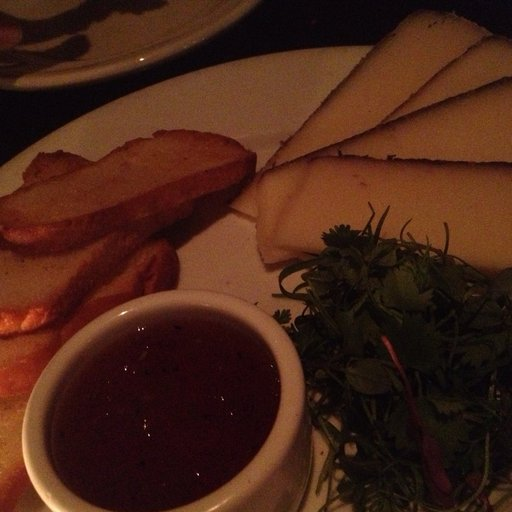

In [6]:
ex_input = ex_sample.get('image')
ex_output = ex_sample.get('output_label_json')

print(f"[INFO] Example Output: \n{ex_output}")
ex_input

## Format data for use with a VLM

Our VLM input requires our data to be formatted using Prompt Template

In [7]:
from pprint import pprint
SYSTEM_MESSAGE = """You are an expert food and drink image extractor.
  You provide structured data to visual inputs classifying them as edible foods/ drink or not
  As well as tilting the image with with a sample food/drink items to lists.
  Finally you extract any and all visible food/drink items to lists.
"""


# User prompt with image inpout and desired output
USER_PROMPT =""" Classify the given input image into food orr not and if edible food or items are present, extract those to a list.
    If no food/drink items are visible return an empty list. Only returen valid JSON in the following form:

    ```json
    {'is_food': 1, # int: 0 if not visible , 1 if food/drink is visible
    'image_title': 'cheese plate', # str: short ffood related ttle foe what food/drink is present in the image, leave blank if not known
     'food_items': ['toast', 'herb garnish', 'dipping sauce', 'cheese wedge'] # str: list of items of ingridients with respect to the title (food) present in images,
     'drink_items': []# str: list of items of ingridients with respect to the title (drink) present in images
    ```

    """


# Create helper function to map our input/output samples to conversational format
def format_data(sample):
  return{
      "messages": [
          # Message 0: [SYSTEM] System Prompt (setting the scene)
          {
              "role": "system",
              "content": [{"type":"text", "content": SYSTEM_MESSAGE}]
          },

          # Message 1: [USER] User input {image+prompt pair}
          {
              "role":"user",
              "content":[
                  {
                      "type":"text",
                      "text":USER_PROMPT


                  },
                  {
                    "type":"image",
                    "image": sample["image"],
                  }
                  ]
          },
            # Message 2: [MODEL] Idea Model Output (e.g: structured data format)

          {
              "role":"assistant",
              "content":[{"type":"text", "text":sample["output_label_json"] }]
          }

      ]
  }


formatted_sample = format_data(ex_sample)
pprint(formatted_sample)


{'messages': [{'content': [{'content': 'You are an expert food and drink image '
                                       'extractor.\n'
                                       '  You provide structured data to '
                                       'visual inputs classifying them as '
                                       'edible foods/ drink or not\n'
                                       '  As well as tilting the image with '
                                       'with a sample food/drink items to '
                                       'lists.\n'
                                       '  Finally you extract any and all '
                                       'visible food/drink items to lists.\n',
                            'type': 'text'}],
               'role': 'system'},
              {'content': [{'text': ' Classify the given input image into food '
                                    'orr not and if edible food or items are '
                                    'present,

In [8]:
# Format each item in the original dataset keeping the PIL image type

dataset_processed = [format_data(sample) for sample in dataset.get("train")]
dataset_processed[0]

{'messages': [{'role': 'system',
   'content': [{'type': 'text',
     'content': 'You are an expert food and drink image extractor.\n  You provide structured data to visual inputs classifying them as edible foods/ drink or not\n  As well as tilting the image with with a sample food/drink items to lists.\n  Finally you extract any and all visible food/drink items to lists.\n'}]},
  {'role': 'user',
   'content': [{'type': 'text',
     'text': " Classify the given input image into food orr not and if edible food or items are present, extract those to a list.\n    If no food/drink items are visible return an empty list. Only returen valid JSON in the following form:\n\n    ```json\n    {'is_food': 1, # int: 0 if not visible , 1 if food/drink is visible\n    'image_title': 'cheese plate', # str: short ffood related ttle foe what food/drink is present in the image, leave blank if not known\n     'food_items': ['toast', 'herb garnish', 'dipping sauce', 'cheese wedge'] # str: list of items of

In [9]:
# TK:  this is taking too long, maybe find a better method? -> usually map() should get the job done... Maybe use Copilot?
# dataset = dataset.map(format_data,batched = False)

## Running a sample through the base model

Let's see how a non-fine-tune model performs on our task:
Let us start off with `Gemma-3n-E2B-it`

In [10]:
from huggingface_hub import login
login()  # Paste your token when prompted


In [11]:
from transformers import AutoModelForImageTextToText, AutoProcessor, BitsAndBytesConfig
import torch, gc, platform, os 


In [13]:
from transformers import AutoModelForImageTextToText, AutoProcessor, BitsAndBytesConfig
import torch, gc, platform, os

# Free any leftover VRAM from previous failed loads
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

IS_WINDOWS = platform.system().lower().startswith("win")
HAS_CUDA = torch.cuda.is_available()

# Try small models first so you can iterate quickly
MODEL_CANDIDATES = [
    "HuggingFaceTB/SmolVLM-500M-Instruct",
    "Qwen/Qwen2-VL-2B-Instruct",
    "google/gemma-3n-E2B-it",
]

# Prefer float16 on GPU for lower memory usage
compute_dtype = torch.float16 if HAS_CUDA else torch.float32
os.makedirs("offload", exist_ok=True)

def print_model_placement(model, model_id):
    dm = getattr(model, "hf_device_map", None)
    if dm is not None:
        print(f"Loaded {model_id}. Device map: {dm}")
    else:
        try:
            first_param_device = next(model.parameters()).device
            print(f"Loaded {model_id}. First param on device: {first_param_device}")
        except StopIteration:
            print(f"Loaded {model_id}. (no parameters found to inspect device)")

model, processor, MODEL_ID = None, None, None
last_error = None

for candidate in MODEL_CANDIDATES:
    try:
        print(f"[INFO] Trying model: {candidate}")

        # Only attempt 4-bit for non-Windows CUDA setups
        if (not IS_WINDOWS) and HAS_CUDA:
            bnb_config = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=compute_dtype,
            )
            model = AutoModelForImageTextToText.from_pretrained(
                candidate,
                quantization_config=bnb_config,
                device_map="auto",
                torch_dtype=compute_dtype,
                low_cpu_mem_usage=True,
                token=True,
                attn_implementation="eager",
            )
        else:
            model = AutoModelForImageTextToText.from_pretrained(
                candidate,
                device_map="auto",
                max_memory={0: "5GiB", "cpu": "10GiB"} if HAS_CUDA else {"cpu": "10GiB"},
                offload_folder="offload",
                offload_state_dict=True,
                torch_dtype=compute_dtype,
                low_cpu_mem_usage=True,
                token=True,
                attn_implementation="eager",
            )

        processor = AutoProcessor.from_pretrained(candidate, token=True)
        MODEL_ID = candidate
        print_model_placement(model, MODEL_ID)
        break

    except Exception as e:
        last_error = e
        print(f"[WARN] Failed for {candidate}: {type(e).__name__}: {e}")
        gc.collect()
        if HAS_CUDA:
            torch.cuda.empty_cache()

if model is None:
    raise RuntimeError(f"All model candidates failed. Last error: {last_error}")

print(f"[INFO] Active MODEL_ID: {MODEL_ID}")

[INFO] Trying model: HuggingFaceTB/SmolVLM-500M-Instruct


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

...

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded HuggingFaceTB/SmolVLM-500M-Instruct. First param on device: cpu
[INFO] Active MODEL_ID: HuggingFaceTB/SmolVLM-500M-Instruct


In [14]:
# Build the input messages (same format the pipeline would use internally)
messages = [
    {"role": "system", "content": [{"type": "text", "text": SYSTEM_MESSAGE}]},
    {"role": "user", "content": [
        {"type": "text", "text": USER_PROMPT},
        {"type": "image", "image": ex_input},
    ]},
]

# Processor converts messages + image into model-ready tensors
inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
)

# Move to device — only cast FLOAT tensors to model dtype, keep int tensors (input_ids) as-is
inputs = {
    k: v.to(device=model.device, dtype=model.dtype) if v.is_floating_point()
    else v.to(device=model.device)
    for k, v in inputs.items()
}

# Generate
with torch.no_grad():
    output_ids = model.generate(**inputs, max_new_tokens=256)

# Decode — skip the input tokens to get only the model's response
generated_ids = output_ids[:, inputs["input_ids"].shape[1]:]
base_model_output = processor.decode(generated_ids[0], skip_special_tokens=True)
print(base_model_output)

 Plate of food with a bowl of sauce and a few pieces of bread.


### Let us try to run ```HuggingFaceTB/SmolVLM-500M-Instruct``` using the `pipeline` function from `transformers`

In [ ]:
from transformers import pipeline 
pipe = pipeline(
    "image-text-to-text",
    model = model,
    processor=processor
)

example_base_model_input = dataset_processed[0]['messages'][:2]
base_model_output = pipe(text=example_base_model_input, max_new_tokens=256)



Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'input_text': [{'role': 'system', 'content': [{'type': 'text', 'content': 'You are an expert food and drink image extractor.\n  You provide structured data to visual inputs classifying them as edible foods/ drink or not\n  As well as tilting the image with with a sample food/drink items to lists.\n  Finally you extract any and all visible food/drink items to lists.\n'}]}, {'role': 'user', 'content': [{'type': 'text', 'text': " Classify the given input image into food orr not and if edible food or items are present, extract those to a list.\n    If no food/drink items are visible return an empty list. Only returen valid JSON in the following form:\n\n    ```json\n    {'is_food': 1, # int: 0 if not visible , 1 if food/drink is visible\n    'image_title': 'cheese plate', # str: short ffood related ttle foe what food/drink is present in the image, leave blank if not known\n     'food_items': ['toast', 'herb garnish', 'dipping sauce', 'cheese wedge'] # str: list of items of ingridients wi

In [23]:
print(f"[INFO] Base model input (text only):\n {example_base_model_input}\n")
print(f"[INFO] Base model output:\n{base_model_output[0]["generated_text"][-1]["content"]}\n")
print(f"[INFO] Desired output:\n {dataset_processed[0]["messages"][-1]["content"][0]["text"]}")

[INFO] Base model input (text only):
 [{'role': 'system', 'content': [{'type': 'text', 'content': 'You are an expert food and drink image extractor.\n  You provide structured data to visual inputs classifying them as edible foods/ drink or not\n  As well as tilting the image with with a sample food/drink items to lists.\n  Finally you extract any and all visible food/drink items to lists.\n'}]}, {'role': 'user', 'content': [{'type': 'text', 'text': " Classify the given input image into food orr not and if edible food or items are present, extract those to a list.\n    If no food/drink items are visible return an empty list. Only returen valid JSON in the following form:\n\n    ```json\n    {'is_food': 1, # int: 0 if not visible , 1 if food/drink is visible\n    'image_title': 'cheese plate', # str: short ffood related ttle foe what food/drink is present in the image, leave blank if not known\n     'food_items': ['toast', 'herb garnish', 'dipping sauce', 'cheese wedge'] # str: list of i

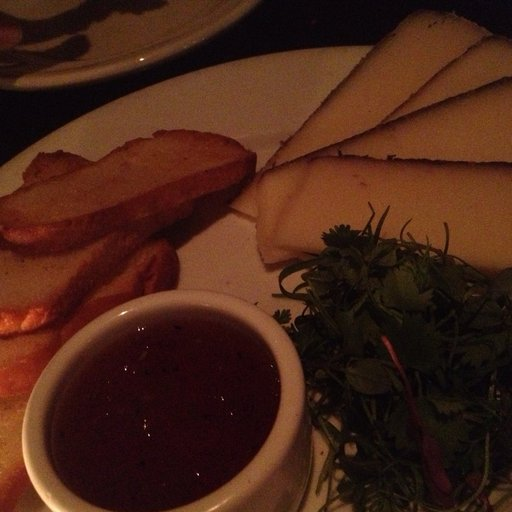

In [31]:
example_base_model_input[1]['content'][1]['image']


### Loading the model without using pipeline: 
Since our base model did not give us the result we wanted it to give in, let us now try perform fine-tuning so that we can bring it to the output we want + some extra training 

What I've seen so far is that `transformers.pipeline` allows simple loading and inference but we would have to perform customizations we'll want to load the model directly

In [34]:
import torch 
from transformers import AutoProcessor, AutoModelForImageTextToText

print(f"[INFO] Using model: {MODEL_ID}")

# Define the model init args
model_kwargs = dict(
    attn_implementation = 'eager',
    dtype = torch.float16,
    device_map = 'auto'
)

model = AutoModelForImageTextToText.from_pretrained(MODEL_ID,**model_kwargs)
processor = AutoProcessor.from_pretrained(MODEL_ID)

[INFO] Using model: HuggingFaceTB/SmolVLM-500M-Instruct


Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

In [35]:
model

Idefics3ForConditionalGeneration(
  (model): Idefics3Model(
    (vision_model): Idefics3VisionTransformer(
      (embeddings): Idefics3VisionEmbeddings(
        (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
        (position_embedding): Embedding(1024, 768)
      )
      (encoder): Idefics3Encoder(
        (layers): ModuleList(
          (0-11): 12 x Idefics3EncoderLayer(
            (self_attn): Idefics3VisionAttention(
              (k_proj): Linear(in_features=768, out_features=768, bias=True)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (mlp): Idefics3VisionMLP(
              (activation_fn): GELUTanh()
              (fc1): Linear(in_features=768, out

Taking note of the major components: 
* `vision_model`: This will encode the image, in our case of SMOLVLM2, it uses `SigLIP` vision language model as an encoder
* `text_model` : This will encode our text into numerical representations. Uner the hood SmolVLM2 uses `SmolVLM2-500M-Instruct`
* `connector` : This module will connect the induvidual `vision_model` and `text_model` and combine them into the same feature space.
* `lm_head`: This module will output tokens that have been conditioned on both vision and text data.

For now I shall try fine-tuning components except for the `vision_model` as this is what is reflected in the [literature](https://arxiv.org/abs/2503.11576).

NOW Running a sample through our model

In [36]:
example_base_model_input[1]

{'role': 'user',
 'content': [{'type': 'text',
   'text': " Classify the given input image into food orr not and if edible food or items are present, extract those to a list.\n    If no food/drink items are visible return an empty list. Only returen valid JSON in the following form:\n\n    ```json\n    {'is_food': 1, # int: 0 if not visible , 1 if food/drink is visible\n    'image_title': 'cheese plate', # str: short ffood related ttle foe what food/drink is present in the image, leave blank if not known\n     'food_items': ['toast', 'herb garnish', 'dipping sauce', 'cheese wedge'] # str: list of items of ingridients with respect to the title (food) present in images,\n     'drink_items': []# str: list of items of ingridients with respect to the title (drink) present in images\n    ```\n\n    "},
  {'type': 'image', 'image': <PIL.Image.Image image mode=RGB size=512x512>}]}

In [ ]:
example_chat_template_input = processor.apply_chat_template(
    [example_base_model_input[1]],
    add_generation_prompt = True, 
    
)